### Medidas Campos Eléctricos y Magnéticos Slayer Exciter

#### Campo Eléctrico

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df_Elec = pd.read_excel('CampoElectricoMV.ods', engine='odf')
df_Elec['Tiempo'] = df_Elec.index # A cada fila se le asocia un segundo de tiempo

print(df_Elec.head())


     0cm     5cm    10cm   15cm   20cm   25cm   30cm  Tiempo
0  151.9   -32.0   -52.3   80.2  121.5  160.3  281.3       0
1  152.9   -30.6   -50.8   80.8  121.7  160.3  280.0       1
2  155.4   -30.1   -50.8  306.9  122.0  160.3  205.1       2
3  153.3   -30.1  9240.0  298.1  452.1  160.3  324.6       3
4  153.3  6110.0  9640.0  322.3  489.3  495.4  351.7       4


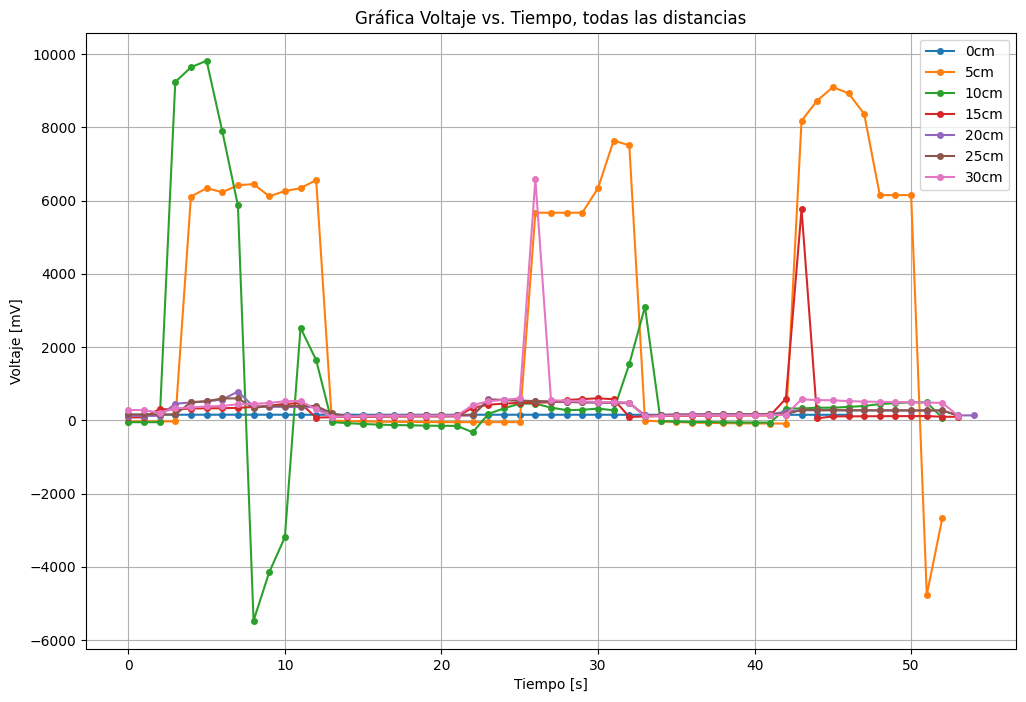

In [24]:
plt.figure(figsize=(12, 8))

# Grafica cada columna (excepto la columna 'Tiempo')
for columna in df_Elec.columns[:-1]:
    plt.plot(df_Elec['Tiempo'], df_Elec[columna], marker='o', markersize="4", label=columna)

# Configura título y etiquetas
plt.title('Gráfica Voltaje vs. Tiempo, todas las distancias')
plt.xlabel('Tiempo [s]')
plt.ylabel('Voltaje [mV]')
plt.legend(loc='upper right')
plt.grid(True)

# Muestra la gráfica
plt.show()

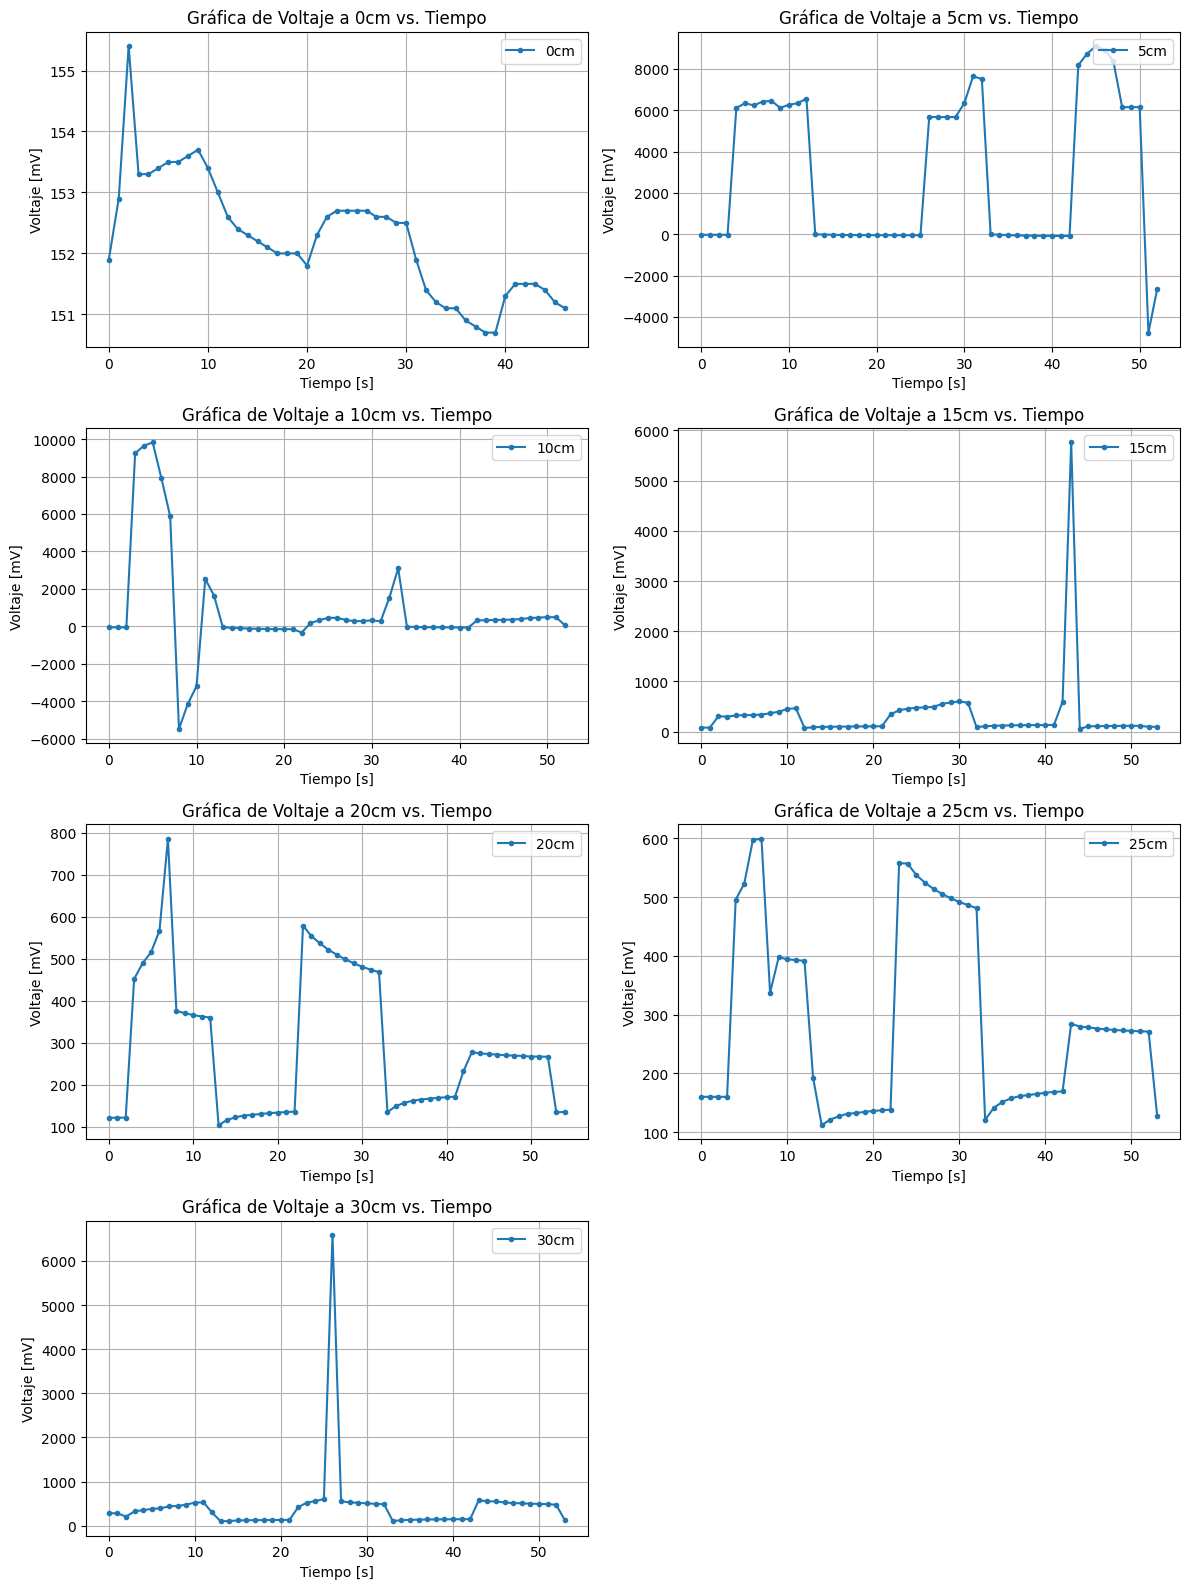

In [25]:

# Crear una figura con 7 subgráficas en 2 columnas
fig, axs = plt.subplots(4, 2, figsize=(12, 16))  # 4 filas, 2 columnas

# Aplanar la matriz de ejes para facilitar la iteración
axs = axs.flatten()

# Grafica cada columna (excepto la columna 'Tiempo')
for i, columna in enumerate(df_Elec.columns[:-1]):
    axs[i].plot(df_Elec['Tiempo'], df_Elec[columna], marker='o', markersize=3, label=columna)
    axs[i].set_title(f'Gráfica de Voltaje a {columna} vs. Tiempo')
    axs[i].set_xlabel('Tiempo [s]')
    axs[i].set_ylabel('Voltaje [mV]')
    axs[i].legend(loc='upper right')
    axs[i].grid(True)

# Eliminar subgráficas vacías si hay menos de 8
for i in range(len(df_Elec.columns) - 1, len(axs)):
    fig.delaxes(axs[i])

# Ajustar el espacio entre subgráficas
fig.tight_layout()

# Muestra la figura
plt.show()


Para hallar los valores de campo eléctrico usaremos la ecuación:

$$ V = \frac{K \cdot q}{r} $$

$$ E = \frac{V}{d} $$

Pero inicialmente es necesario calcular el error propio del multímetro para las diferencias de voltaje:

- 0mV a 60mV  --> $\pm (1.2\% + 5*0.01)$
- 60 mV a 600mV --> $\pm (1.2\% + 5*0.1)$
- 600mV a 6000mV --> $\pm (1.0\% + 3*1)$
- 6000mV a 60000mV --> $\pm (1.0\% + 3*10)$

In [14]:
import pandas as pd

def calcular_error(df):
    # Crear una copia del DataFrame para no modificar el original
    df_copy = df.copy()
    
    for column in df.columns:
        if df[column].dtype in [int, float]:  # Asegurarse de que la columna contenga datos numéricos
            error_column = 'e_' + column
            df_copy[error_column] = df[column].apply(calcular_valor_error)
            # Reorganizar las columnas para que la columna de error quede a la derecha de la columna original
            cols = df_copy.columns.tolist()
            col_idx = cols.index(column)
            cols.insert(col_idx + 1, cols.pop(cols.index(error_column)))
            df_copy = df_copy[cols]

    return df_copy

def calcular_valor_error(value):
    value = abs(value)
    if 0 <= value <= 60:
        error = value * 0.012 + 5 * 0.01
    elif 60 < value <= 600:
        error = value * 0.012 + 5 * 0.1
    elif 600 < value <= 6000:
        error = value * 0.01 + 3 * 1
    elif 6000 < value <= 60000:
        error = value * 0.01 + 3 * 10
    else:
        error = 0  # Asumimos que fuera de los rangos dados no hay error
    return error

# Ejemplo de uso
data = {
    'col1': [50, 500, 5500, 70000],
    'col2': [70, 700, 7000, 80000]
}
df = pd.DataFrame(data)
df_con_errores = calcular_error(df)
print(df_con_errores)


    col1  e_col1   col2  e_col2
0     50    0.65     70    1.34
1    500    6.50    700   10.00
2   5500   58.00   7000  100.00
3  70000    0.00  80000    0.00


In [34]:
df_Elec_con_errores = calcular_error(df_Elec)

     0cm   e_0cm     5cm  e_5cm    10cm  e_10cm   15cm  e_15cm   20cm  e_20cm  \
0  151.9  2.3228   -32.0    0.0   -52.3     0.0   80.2  1.4624  121.5  1.9580   
1  152.9  2.3348   -30.6    0.0   -50.8     0.0   80.8  1.4696  121.7  1.9604   
2  155.4  2.3648   -30.1    0.0   -50.8     0.0  306.9  4.1828  122.0  1.9640   
3  153.3  2.3396   -30.1    0.0  9240.0   122.4  298.1  4.0772  452.1  5.9252   
4  153.3  2.3396  6110.0   91.1  9640.0   126.4  322.3  4.3676  489.3  6.3716   

    25cm  e_25cm   30cm  e_30cm  Tiempo  e_Tiempo  
0  160.3  2.4236  281.3  3.8756       0     0.050  
1  160.3  2.4236  280.0  3.8600       1     0.062  
2  160.3  2.4236  205.1  2.9612       2     0.074  
3  160.3  2.4236  324.6  4.3952       3     0.086  
4  495.4  6.4448  351.7  4.7204       4     0.098  


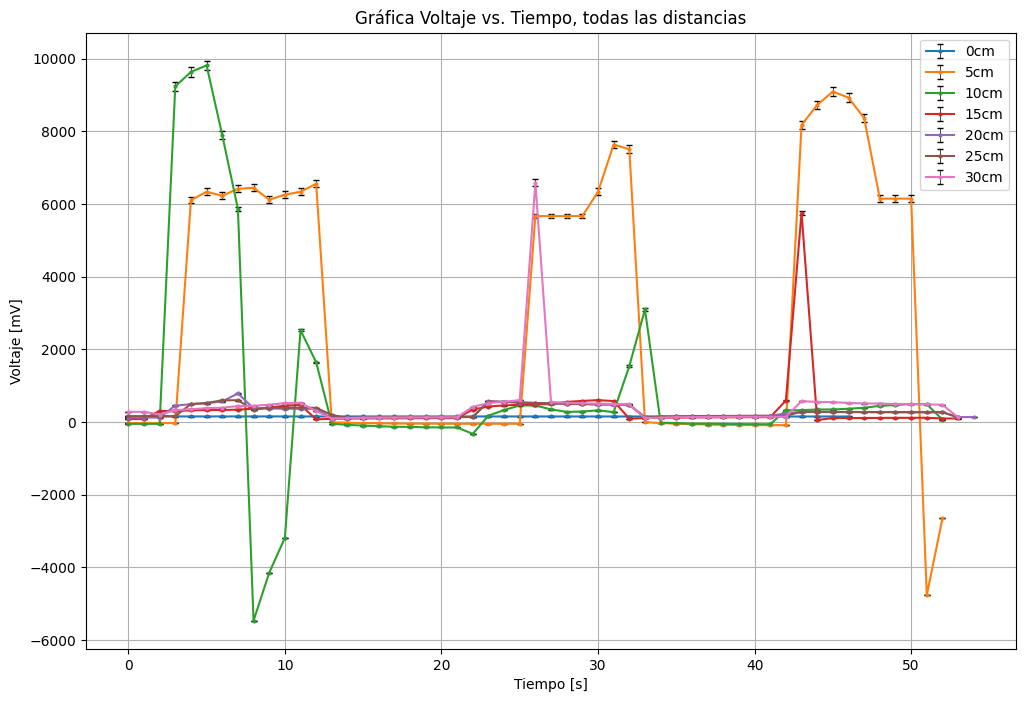

In [35]:
df_Elec = pd.read_excel('CampoElectricoMV.ods', engine='odf')
df_Elec['Tiempo'] = df_Elec.index  # A cada fila se le asocia un segundo de tiempo

# Calcular errores
def calcular_error(df):
    # Crear una copia del DataFrame para no modificar el original
    df_copy = df.copy()
    
    for column in df.columns:
        if df[column].dtype in [int, float]:  # Asegurarse de que la columna contenga datos numéricos
            error_column = 'e_' + column
            df_copy[error_column] = df[column].apply(calcular_valor_error)
            # Reorganizar las columnas para que la columna de error quede a la derecha de la columna original
            cols = df_copy.columns.tolist()
            col_idx = cols.index(column)
            cols.insert(col_idx + 1, cols.pop(cols.index(error_column)))
            df_copy = df_copy[cols]

    return df_copy

def calcular_valor_error(value):
    if 0 <= value <= 60:
        error = value * 0.012 + 5 * 0.01
    elif 60 < value <= 600:
        error = value * 0.012 + 5 * 0.1
    elif 600 < value <= 6000:
        error = value * 0.01 + 3 * 1
    elif 6000 < value <= 60000:
        error = value * 0.01 + 3 * 10
    else:
        error = 0  # Asumimos que fuera de los rangos dados no hay error
    return error

# Calcular errores y agregar las columnas de error al DataFrame
df_Elec = calcular_error(df_Elec)

print(df_Elec.head())

# Crear la gráfica con barras de error
plt.figure(figsize=(12, 8))

# Grafica cada columna (excepto la columna 'Tiempo' y las de error)
for columna in df_Elec.columns:
    if columna != 'Tiempo' and not columna.startswith('e_'):
        error_column = 'e_' + columna
        if error_column in df_Elec.columns:
            plt.errorbar(df_Elec['Tiempo'], df_Elec[columna], yerr=df_Elec[error_column], fmt='-o', markersize=2, label=columna, ecolor='black', capsize=2, elinewidth=0.5)
        else:
            plt.plot(df_Elec['Tiempo'], df_Elec[columna], marker='o', markersize=4, label=columna)

# Configura título y etiquetas
plt.title('Gráfica Voltaje vs. Tiempo, todas las distancias')
plt.xlabel('Tiempo [s]')
plt.ylabel('Voltaje [mV]')
plt.legend(loc='upper right')
plt.grid(True)
plt.savefig('grafica_voltaje_vs_tiempo.jpg', dpi=400)
# Muestra la gráfica
plt.show()

$$N = \left ( \frac{V_{cc}}{2} + \frac{1.3\ mV}{Gauss} * B \right) * \frac{1023}{3.3V}$$